# Daniyal Khan || 221A061 || 19

In [1]:
# Daniyal Khan || 221A061

# Install required libraries
!pip install youtube-comment-downloader
!pip install networkx pandas matplotlib python-louvain

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from youtube_comment_downloader import YoutubeCommentDownloader
import community as community_louvain
from collections import Counter


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 8.7 MB/s eta 0:00:00


In [2]:
# Daniyal Khan || 221A061

video_url = "https://www.youtube.com/watch?v=yACdz8V5IUg"

In [3]:
# Daniyal Khan || 221A061

downloader = YoutubeCommentDownloader()

comments = []
users = []

for comment in downloader.get_comments_from_url(video_url):
    comments.append(comment['text'])
    users.append(comment['author'])

print("Total Comments Downloaded:", len(comments))

df = pd.DataFrame({
    "user": users,
    "comment": comments
})

df.head()


Total Comments Downloaded: 11


,user,comment
0,@DeepakKr-k5i,Sir aage ka video bna dijiye
1,@Saniyamirza-v8w,Sir unit 4 and 5 ke important question laiya .
2,@askyourselfanything,Aur important question layge sir
3,@ArmanHussain-jd6bo,Sir unit wise 2 se 3 question answer laaiyena ...
4,@nikhilff4155,sir pps mai bs apke sare question padh lenge t...


In [4]:
# Daniyal Khan || 221A061

G = nx.Graph()

for user in df['user']:
    G.add_node(user)

# connect users who commented near each other
for i in range(len(users)-1):
    G.add_edge(users[i], users[i+1])

print("Total Users:", G.number_of_nodes())
print("Total Connections:", G.number_of_edges())


Total Users: 6
Total Connections: 7


In [6]:
# Daniyal Khan || 221A061

import community.community_louvain as community_louvain

partition = community_louvain.best_partition(G)

communities = Counter(partition.values())

print("\nDetected Communities:")
print(communities)



Detected Communities:
Counter({1: 3, 0: 3})


In [7]:
# Daniyal Khan || 221A061

degree_centrality = nx.degree_centrality(G)

top_influencers = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop Influential Users:")
for user, score in top_influencers:
    print(user, score)



Top Influential Users:
@bhatisirkipathshala 0.8
@ArmanHussain-jd6bo 0.6000000000000001
@Saniyamirza-v8w 0.4
@askyourselfanything 0.4
@nikhilff4155 0.4
@DeepakKr-k5i 0.2


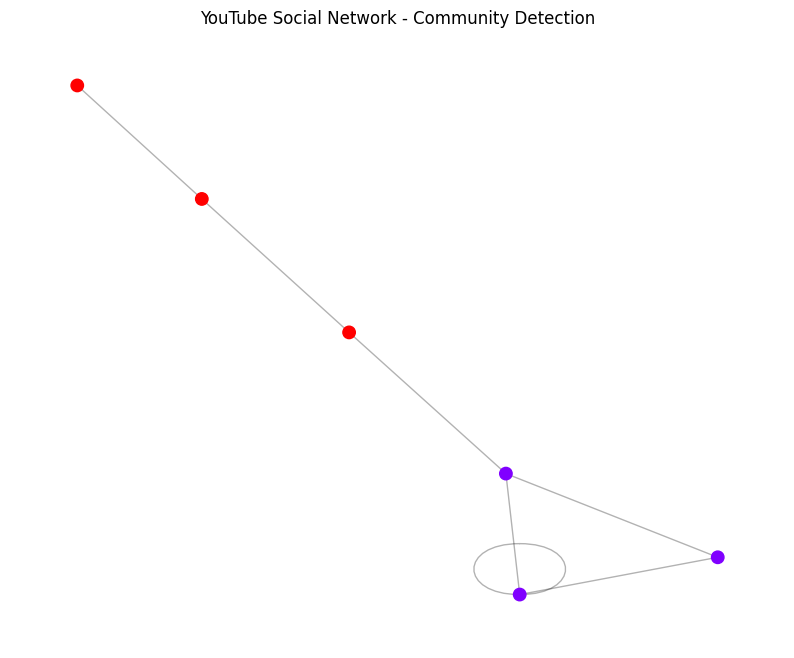

In [8]:
# Daniyal Khan || 221A061

pos = nx.spring_layout(G)

plt.figure(figsize=(10,8))

colors = [partition[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=80, node_color=colors, cmap=plt.cm.rainbow)
nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title("YouTube Social Network - Community Detection")
plt.axis("off")
plt.show()
